# Elastic wave temporal convergence tutorial

This tutorial was prepared by Alexandre Olender: olender@usp.br

This tutorial demonstrates how to investigate temporal
convergence for isotropic elastic wave propagation in Spiro.

We will:
1. Introduce the concept of convergence;
2. Discuss what to check before performing a convergence analysis;
3. Investigate temporal convergence by refining the time step.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import spyro
from spyro.tools.error_measure import MeasureError

## 1. What is convergence?

A numerical solution should approach the exact solution as the discretization is refined according to the order of convergence.

For a numerical solution with error E and discretization parameter $\text{d}t$, we expect

$ \frac{|E(\text{d}t)|}{|\text{d}t|^p} \approx C $,

where p is the convergence order (don't confuse this with spatial polynomial order) and $C$ is a constant. The convergence order $p$ describes how quickly numerical error decreases as discretization is refined.

The same is true for our mesh discretization parameter of edge length $h$.

In Spiro we consider two types of discretization:

* Temporal discretization: the time step $\text{d}t$;
* Spatial discretization: the mesh edge length $h$.

However, for this tutorial we will focus on the temporal discretizaion. Therefore, we will use a very small spatial discretization for the error from our temporal discretization to dominate.

Let us set up an homogeneous isotropic medium elastic wave propagation dictionary. The same problem will be solved subsequently with varying $\text{d}t$ values.

In [2]:
vp = 1.5
vs = 1.0
rho = 0.1

source_z = -2.0
receiver_z = -2.5
source_locations = [(source_z, -source_z)]
receiver_locations = [(receiver_z, -receiver_z)]
final_time = 1.2
initial_dt = 2.5e-3

dictionary = {
    "options": {
        "cell_type": "Q",
        "variant": "lumped",
        "degree": 4,
        "dimension": 2,
    },
    "parallelism": {
        "type": "automatic",
    },
    "mesh": {
        "length_z": 4.0,
        "length_x": 4.0,
        "mesh_type": "firedrake_mesh",
    },
    "acquisition": {
        "source_type": "ricker",
        "source_locations": source_locations,
        "frequency": 5.0,
        "delay": 0.2,
        "delay_type": "time",
        "receiver_locations": receiver_locations,
        "amplitude": np.array([0.0, 1.0]),
    },
    "time_axis": {
        "initial_time": 0.0,
        "final_time": final_time,
        "dt": initial_dt,
        "output_frequency": 100,
        "gradient_sampling_frequency": 1,
    },
    "visualization": {
        "forward_output": False,
        "fwi_velocity_model_output": False,
        "gradient_output": False,
        "adjoint_output": False,
        "debug_output": False,
    },
}
dictionary["synthetic_data"] = {
    "type": "object",
    "density": rho,
    "p_wave_velocity": vp,
    "s_wave_velocity": vs,
    "real_velocity_file": None,
}
wave = spyro.IsotropicWave(dictionary)


Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters


/workspaces/qol_upgrades/spyro/solvers/wave.py:171: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


# 2. Before looking at convergence

Before computing convergence rates, it is important to verify that the numerical and reference solutions are correctly aligned in time. A mismatch between two otherwise similar waveforms can sometimes be caused by a simple time shift.  This can occur simply because:
* Different conventions for the initial or final time;
* Differences in the source-wavelet delay;
* Differences in how the time-stepping scheme stores the solution.

However, this wave-fornt time shift can also signify dispersion error or something else.

Therefore, a time shift should be investigated before interpreting the difference between two waveforms as a numerical error.

To analyze this, we will begin by adding a wrapper to Spiro's 2D analytical solution method, so we can vary only the timestep and get an analytical solution result measured at that timestep.

Importantly, we should **not simply shift the numerical solution or the analytical solution before computing the convergence error**. Doing so could hide a genuine temporal discretization error. The purpose of this section is only to diagnose whether the two signals are aligned.

In [3]:
offsets = np.array(source_locations[0]) - np.array(receiver_locations[0])

def get_analytical_solution(dt):
    return spyro.utils.analytical_solution_elastic(
        source_type="force_source",
        offsets=offsets,
        p_wave_velocity=vp,
        s_wave_velocity=vs,
        density=rho,
        amplitude=1.0,
        frequency=5.0,
        time_delay=0.2,
        final_time=final_time,
        dt=dt,
        force_direction=1,
        dimension=2,
    )

Let us set a small element length h of 0.05 km to begin and get our first numerical result. For a simulation with these velocities and element order we would usually use bigger elements. However, since we have't yet looked into spatial convergence (that is a subsequent tutorial), the spatial discretization should be sufficienntly fine .

In [4]:
%%capture
wave.set_mesh(input_mesh_parameters={"edge_length": 0.05, "periodic": False})
wave.forward_solve()

We can compare our numerical solution to our analytical solution visually by looking at the plot of displacement in each direction.

Error in first direction of 0.009414433582834501
Error in first direction of 0.009094928974367068


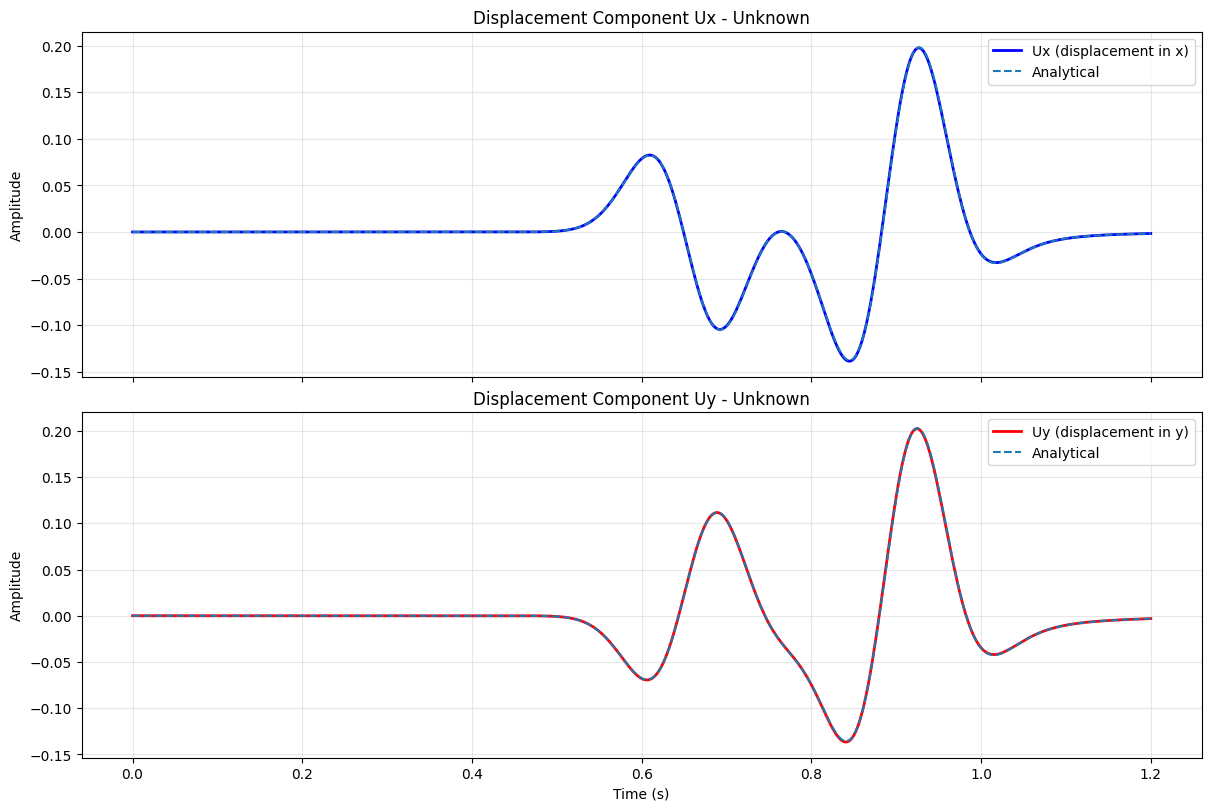

In [5]:
time_vector = spyro.utils.get_time_vector(wave)
fig = spyro.plots.plot_displacement_components(
    time_vector=time_vector,
    receiver_results=wave.forward_solution_receivers[:, 0 ,:],
    hold=True,
)
axes = fig.get_axes()
analytical_solution = get_analytical_solution(2.5e-3)
axes[0].plot(time_vector, analytical_solution[0], "--", label="Analytical")
axes[0].legend()
axes[1].plot(time_vector, analytical_solution[1], "--", label="Analytical")
axes[1].legend()
error_x0 = MeasureError.calculate_normalized_L2_error(wave.forward_solution_receivers[:, 0 , 0], analytical_solution[0])
error_x1 = MeasureError.calculate_normalized_L2_error(wave.forward_solution_receivers[:, 0 , 1], analytical_solution[1])
print(f"Error in first direction of {error_x0}")
print(f"Error in first direction of {error_x1}")

By looking at the figure above, we can clearly see that even with element size of 0.05 km and timestep of 0.0025 s we are very close to our anaylitical solution. TO demonstrate the influence of a time shift in a L2 error measurement, I will ariticially shift my analytical solution one time-step so we can look at how it would seem if it was shifted. 

Error in first direction of 0.08772343098878459
Error in first direction of 0.08503529926980374


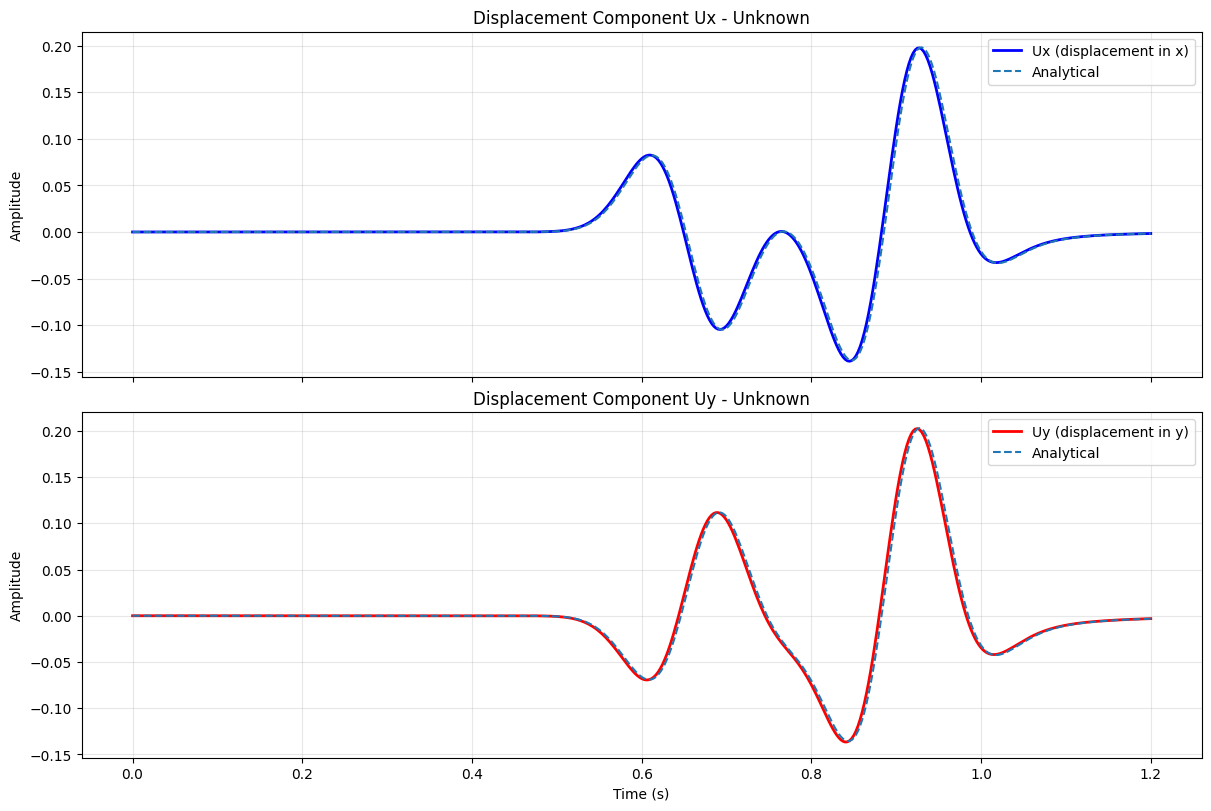

In [6]:
shifted_analytical_solution = [
    analytical_solution[0].copy(),
    analytical_solution[1].copy(),
]
shifted_analytical_solution[0][1:] = shifted_analytical_solution[0][:-1]
shifted_analytical_solution[1][1:] = shifted_analytical_solution[1][:-1]

time_vector = spyro.utils.get_time_vector(wave)
fig = spyro.plots.plot_displacement_components(
    time_vector=time_vector,
    receiver_results=wave.forward_solution_receivers[:, 0 ,:],
    hold=True,
)
axes = fig.get_axes()
analytical_solution = get_analytical_solution(0.005)
axes[0].plot(time_vector, shifted_analytical_solution[0], "--", label="Analytical")
axes[0].legend()
axes[1].plot(time_vector, shifted_analytical_solution[1], "--", label="Analytical")
axes[1].legend()
shifted_error_x0 = MeasureError.calculate_normalized_L2_error(wave.forward_solution_receivers[:, 0 , 0], shifted_analytical_solution[0])
shifted_error_x1 = MeasureError.calculate_normalized_L2_error(wave.forward_solution_receivers[:, 0 , 1], shifted_analytical_solution[1])
print(f"Error in first direction of {shifted_error_x0}")
print(f"Error in first direction of {shifted_error_x1}")

Even though the solution looks fine in both graphs an error measurement can increase signifcantly in these cases. This can dominate our error measurements and invalidade our convergence analysis. Here, for example, we have:

In [7]:
error_increase_x0 = 100 * np.abs(error_x0-shifted_error_x0)/error_x0
error_increase_x1 = 100 * np.abs(error_x1-shifted_error_x1)/error_x1

print(f"Error increase of {error_increase_x0}% and {error_increase_x1}%.")

Error increase of 831.7972262158419% and 834.9748580716267%.


We can quantify this shift using the cross-correlation between signals. SInce I shifted one timestep I expect the measurement to have an absolute value equal to a timestep (0.0025).

In [8]:
from scipy.signal import correlate

def estimate_time_shift(
    time_vector,
    numerical,
    reference,
):
    """Estimate the time shift between numerical and reference signals."""
    numerical = numerical - np.mean(numerical)
    reference = reference - np.mean(reference)

    correlation = correlate(
        numerical,
        reference,
        mode="full",
    )

    lag_samples = np.argmax(correlation) - (len(reference) - 1)

    dt = time_vector[1] - time_vector[0]

    return lag_samples * dt

time_shift = estimate_time_shift(time_vector, wave.forward_solution_receivers[:, 0 , 0], shifted_analytical_solution[0])

print(f"Time shift observed of {time_shift}.")

Time shift observed of -0.0025.


## 3. Investigate temporal convergence

To investigate temporal convergence, we keep the spatial discretization
fixed and progressively reduce the time step. The spatial discretization should be sufficiently fine so that the temporal error is the dominant source of numerical error. Since we are using a central convergence timestepping scheme we should notive second order converge in time.

For each timestep, we will:
* Calculate a numerical result;
* Calculate an analytical result with the same time_vector values;
* Calculate a normalized L2 error;

Afterwards, we will compare how the error changes with a decrease of $\textit{d}t$, calculate the convergence order and compare it to the expected

In [9]:
def get_wave_propagation_result(wave, dt):
    wave.dt = dt
    wave.forward_solve()
    return wave.forward_solution_receivers

In [10]:
dts = [
    2.5e-3,
    2e-3,
    1.25e-3,
    0.8e-3,
]

errors = []

for dt in dts:
    numerical_result = get_wave_propagation_result(wave, dt)
    analytical_result = get_analytical_solution(dt)

    error = MeasureError.calculate_normalized_L2_error(
        numerical_result[:, 0, 0],
        analytical_result[0],
    )

    print(error)
    errors.append(error)

theory = [t**2 for t in dts]
theory = [errors[0] * th / theory[0] for th in theory]



Solving Forward Problem
Simulation time is:        0.0 seconds


/usr/local/lib/python3.12/dist-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:       0.25 seconds
Simulation time is:        0.5 seconds
Simulation time is:       0.75 seconds
Simulation time is:        1.0 seconds
Simulation time is:        1.2 seconds
0.009414433582834501

Solving Forward Problem
Simulation time is:        0.0 seconds
Simulation time is:        0.2 seconds
Simulation time is:        0.4 seconds
Simulation time is:        0.6 seconds
Simulation time is:        0.8 seconds
Simulation time is:        1.0 seconds
Simulation time is:        1.2 seconds
0.006042760307370035

Solving Forward Problem
Simulation time is:        0.0 seconds
Simulation time is:      0.125 seconds
Simulation time is:       0.25 seconds
Simulation time is:      0.375 seconds
Simulation time is:        0.5 seconds
Simulation time is:      0.625 seconds
Simulation time is:       0.75 seconds
Simulation time is:      0.875 seconds
Simulation time is:        1.0 seconds
Simulation time is:      1.125 seconds
Simulation time is:        1.2 seconds
0.002391042


Observed temporal convergence order: 1.958


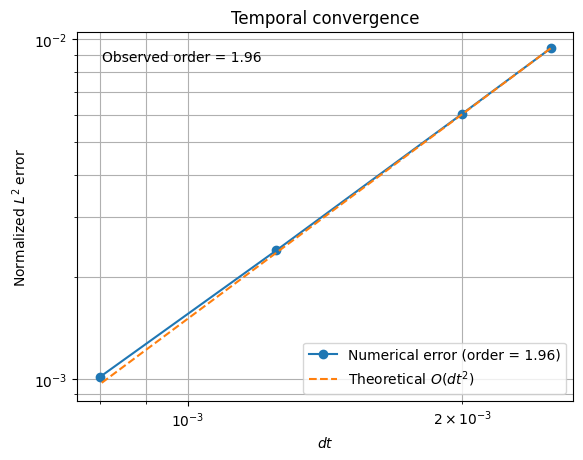

In [11]:
log_dt = np.log(dts)
log_errors = np.log(errors)

p, intercept = np.polyfit(log_dt, log_errors, 1)

print(f"\nObserved temporal convergence order: {p:.3f}")

# Plot convergence
fig, ax = plt.subplots()

ax.loglog(
    dts,
    errors,
    "o-",
    label=f"Numerical error (order = {p:.2f})",
)

ax.loglog(
    dts,
    theory,
    "--",
    label="Theoretical $O(dt^2)$",
)

ax.set_xlabel("$dt$")
ax.set_ylabel("Normalized $L^2$ error")
ax.set_title("Temporal convergence")

ax.grid(True, which="both")
ax.legend()

# Add convergence-rate information to the plot
ax.text(
    0.05,
    0.95,
    f"Observed order = {p:.2f}",
    transform=ax.transAxes,
    verticalalignment="top",
)

plt.show()